In [13]:
#This is the analysis script to make the learning history plots of variables across the training epochs, 
#fig 4 in the manuscript

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import csv
import copy
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import glob
import math
import re
#import cv2
from scipy.stats import entropy
import sys

pd.options.mode.chained_assignment = None 

In [14]:
#moving average of a time series, with window n

def moving_average(a, n=3):
    ret = np.nancumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n
    

In [15]:
MapSize = 96 # map size of arena in episode (usually 48 or 96)
startCSV1 = 0
startCSV2 = 0
windowSize = 250 # moving window size for angle variance
windowSize2 = 100 # for hunger
maxAgent = 4 # number of runs
hasEntropy = 0 # older runs may not have the logp and cross entropy variables, all runs now do
MaxSession = []
EpDF = {}
#agentList = ['f','g','h','i','j','k','l','m','n','o','p','q','r','s','t']
agentList = ['a','b','c','d','e'] # directories should have no numbers in the path for this code to run, 
#this code labels the data directories with a, b, c instead of 0, 1 ,2...

#the scalar behavior data has the scalar variables title row repeated every 1024 timesteps for jax reasons, 
#this removes them
TitleRows = []
for j in range(50):
    if j > 0:
        TitleRows.append(1024*j + j - 1)
print(TitleRows)

# the scalar file name tells the epoch number in training
def get_numbers_from_filename(filename):
    return re.search(r'\d+', filename).group(0)

# scalar variables that can be plotted
PredRateDict = {}
ExplorationDistanceDict = {}
EatRateDict = {}
HungerRateDict = {}
FatigueRateDict = {}
ThirstRateDict = {}
UncertaintyDict = {}
PredKillDict = {}
NumToolsDict = {}
EarlyAngleDict = {}
LateAngleDict = {}
EarlyDistDict = {}
LateDistDict = {}
EntropyDict = {}
CrossEntropyDict = {}
LogPDict = {}
EpNumDict = {}

EarlyAngleHungerDict = {}
LateAngleHungerDict = {}
EarlyDistHungerDict = {}
LateDistHungerDict = {}
EarlyHungerDict = {}
LateHungerDict = {}

listPredRateAll = []
listExplorationDistanceAll = []
listEatRateAll = []
listHungerRateAll = []
listFatigueRateAll = []
listThirstRateAll = []
listUncertaintyAll = []
listPredKillAll = []
listNumToolsAll = []
listEarlyAngleAll = []
listLateAngleAll = []
listEarlyDistAll = []
listLateDistAll = []
listUncertaintyDistAll = []
listEpLengthAll = []
listEntropyAll = []
listCrossEntropy = []
listLogP = []
listEpNumAll = []

listEarlyAngle_Hunger = []
listLateAngle_Hunger = []
listEarlyDist_Hunger = []
listLateDist_Hunger = []
listEarly_Hunger = []
listLate_Hunger = []

listEntropy = []

yOrigin = []
xOrigin = []


for agentID in range(maxAgent):
    ep_ids = []
    agentIDst = str(agentID)
    directoryPath0a = '/Baseline/'
     
    directoryPath0 = directoryPath0a + '' + agentList[agentID] +'/' 
    histDir = directoryPath0a + 'entropy_plots/'
    CHECK_FOLDER = os.path.isdir(histDir)

    # If folder doesn't exist, then create it.
    if not CHECK_FOLDER:
        os.makedirs(histDir)
        print("created folder : ", histDir)
    else:
        print(histDir, "folder already exists.")
    
    directoryPath = directoryPath0 #+ agentIDst+ '/'
    sessionID = 0
    
    PredRate = []
    ExplorationDistance = []
    EatRate = []
    HungerRate = []
    FatigueRate = []
    ThirstRate = []
    Uncertainty = []
    PredKill = []
    NumTools = []
    EpNum = []
    EarlyAngle = []
    LateAngle = []
    EarlyDist = []
    LateDist = []
    Entropy = []
    CrossEntropy = []
    LogP = []

    minLengthAngle = 1000
    minLength = 1000
    
    xxxx = 0
    
    for file_name in glob.glob(directoryPath+'*.csv'):
        
        
        x = pd.read_csv(file_name, low_memory=False)

        Ldata = len(x['pred_delta_x'])

        x.drop(x[x['pred_delta_x'] == 'pred_delta_x'].index, inplace = True)
        x.reset_index(drop=True, inplace=True)
       
        FileNumbers = get_numbers_from_filename(file_name)
        xxxx = xxxx + 1
       
        if Ldata > minLength:           
            # raw scalar output has string formatting from jax                
            x['pred_delta_x'] = pd.to_numeric(x['pred_delta_x'])
            x['delta_x'] = pd.to_numeric(x['delta_x'])
            x['pred_delta_y'] = pd.to_numeric(x['pred_delta_y'])
            x['delta_y'] = pd.to_numeric(x['delta_y'])
            x['melee_on_screen'] = pd.to_numeric(x['melee_on_screen'])
            x['ranged_on_screen'] = pd.to_numeric(x['ranged_on_screen'])
            x['drink'] = pd.to_numeric(x['drink'])
            x['food'] = pd.to_numeric(x['food'])
            x['energy'] = pd.to_numeric(x['energy'])  
            x['player_position_x'] = pd.to_numeric(x['player_position_x'])
            x['player_position_y'] = pd.to_numeric(x['player_position_y'])
            x['is_sleeping'] = pd.to_numeric(x['is_sleeping'])
            if hasEntropy == 1:
                x['entropy'] = pd.to_numeric(x['entropy'])
                x['log_prob'] = pd.to_numeric(x['log_prob'])
            
            x['agentID'] = agentID
            x['sessionID'] = sessionID
            x['xerror'] = x['pred_delta_x'] - x['delta_x'] # spatial uncertainty is diff b/w predicted and actual position, 
            #relative to origin
            x['yerror'] = x['pred_delta_y'] - x['delta_y'] 
            x['distance'] = np.sqrt(x['delta_x']*x['delta_x'] + x['delta_y']*x['delta_y'])
            x['uncertainty'] = np.sqrt(x['xerror']*x['xerror'] + x['yerror']*x['yerror'])  
            x['PredScreen'] = np.ceil ( ( x['melee_on_screen'] + x['ranged_on_screen'] / 2.0 ) )
            x['has_sword'] = pd.to_numeric(x['has_sword'])
            x['has_pick'] = pd.to_numeric(x['has_pick'])          
            
            x['num_monsters_killed'] = pd.to_numeric(x['num_monsters_killed']) - 10 
            #for unclear reasons, 10 is the zero in jax for this variable    
            
            x['agentID'] = agentID
            x['sessionID'] = sessionID
            x['xerror'] = x['pred_delta_x'] - x['delta_x'] 
            x['yerror'] = x['pred_delta_y'] - x['delta_y'] 
            x['atan2'] = x['pred_delta_x']* 0
            
            for j in range(len(x['yerror'])):        
                x.loc[j,'atan2'] = math.atan2(x.loc[j,'delta_y'], x.loc[j,'delta_x'] )
                
            x['abs_atan2'] = abs(x['atan2']) #abs angle from origin of agent
            x['distance'] = np.sqrt(x['delta_x']*x['delta_x'] + x['delta_y']*x['delta_y'])
            x['uncertainty'] = np.sqrt(x['xerror']*x['xerror'] + x['yerror']*x['yerror'])  
            
            #any type of predator on screen or not:
            x['PredScreen'] = np.ceil ( ( x['melee_on_screen'] + x['ranged_on_screen'] / 2.0 ) )
            
            if hasEntropy == 1: #older data files may not have these variables, current/new ones will
                meanCrossEntropy = x.loc[:, 'entropy'].mean()  
                meanLogP = x.loc[:, 'log_prob'].mean()  
                
            meanUncertainty = x.loc[:, 'uncertainty'].mean()
            meanPredRate = x.loc[:, 'PredScreen'].mean()
            meanFatigueRate = x.loc[:, 'energy'].mean()
            meanHungerRate = x.loc[:, 'food'].mean()
            meanExplorationDistance = x.loc[:, 'distance'].mean()
            meanThirstRate = x.loc[:, 'drink'].mean()
            x["has_pick"][x["has_pick"] > 0] = 1
            x["has_sword"][x["has_sword"] > 0] = 1
            meanTools = x.loc[:, 'has_sword'].mean() + x.loc[:, 'has_pick'].mean()
            meanKills = x.loc[:, 'num_monsters_killed'].mean()                                    
            #stdEarlyAngle = x.loc[0:minLengthAngle,'rolling_abs_atan2'].mean()
            #stdLateAngle = x.loc[minLengthAngle:,'rolling_abs_atan2'].mean()            
                            
            temp_stdEarlyAngle = []
            temp_stdLateAngle = []
            temp_EarlyDist = []
            temp_LateDist = []
            temp_entropy = []
            temp_CrossEntropy = []
            temp_LogP = []
            
            #since periodic recording logs happen within a stream of episodes, the first episode in a file usually
            #recording start part way through an episode, so cut out this partial first episode per scalar data file
            x_no_first_ep = x.copy(deep=True)            
            x_no_first_ep.drop(x_no_first_ep[x_no_first_ep['episode_id'] == x.loc[0,'episode_id']].index, inplace = True)  
            x_no_first_ep.reset_index(drop=True, inplace=True)
            
            #option to remove the last episode too, byt we don't have the stats to do this right now and the analysis
            #focuses on the start of the episode more anyways
            #if len(x_no_first_ep.index) > 0:            
            #    x_no_first_ep.drop(x_no_first_ep[x_no_first_ep['episode_id'] == x_no_first_ep.loc[(len(x_no_first_ep['episode_id'])-1),'episode_id']].index, inplace = True)
            
            x_no_first_ep.reset_index(drop=True, inplace=True)
            
            #there are multiple episodes per scalar file, this makes an episode list per file
            EpList = x_no_first_ep['episode_id'].unique()
            print(EpList)
            
            if len(EpList) == 0:
                EpList = x['episode_id'].unique()
            
            check = 0
            
            for eps in range(len(EpList)):
                
                s_stdEarlyAngle = np.nan
                s_stdLateAngle = np.nan
                s_EarlyDist = np.nan
                s_LateDist = np.nan
                
                s_stdEarlyHungerAngle = np.nan
                s_stdLateHungerAngle = np.nan
                s_EarlyHungerDist = np.nan
                s_LateHungerDist = np.nan
                s_EarlyHunger = np.nan
                s_LateHunger = np.nan
                
                path_intensity = np.zeros((MapSize, MapSize))
                
                x_single_ep = x_no_first_ep[(x_no_first_ep['episode_id'] == EpList[eps] )]
                
                x_single_ep.reset_index(drop=True, inplace=True) 
                
                x_single_ep_no_sleep = x_single_ep[(x_single_ep['is_sleeping'] == 0)] 
                x_single_ep_no_sleep.reset_index(drop=True, inplace=True) 
                
                x_no_sleep = x[(x['is_sleeping'] == 0)] 
                x_no_sleep.reset_index(drop=True, inplace=True) 
                
                if len(x_single_ep_no_sleep.index) == 0:
                    for k in range(len(x_no_sleep.index)):                         
                        xi = int(x_no_sleep.loc[k,'player_position_x'])
                        yi = int(x_no_sleep.loc[k,'player_position_y'])
                        path_intensity[xi,yi] = path_intensity[xi,yi] + 1
                    
                if len(x_single_ep_no_sleep.index) > 0:
                    for k in range(len(x_single_ep_no_sleep.index)):                         
                        xi = int(x_single_ep_no_sleep.loc[k,'player_position_x'])
                        yi = int(x_single_ep_no_sleep.loc[k,'player_position_y'])
                        path_intensity[xi,yi] = path_intensity[xi,yi] + 1
                
                _bins = int(np.max(path_intensity))
                
                if _bins == 0:
                    sys.exit()
                path_hist, _ = np.histogram(path_intensity.ravel(), bins=_bins, range=(0, _bins)) 
                prob_dist = path_hist / path_hist.sum()
                #spatial entropy calculation of position heatmap for an episode
                path_entropy = entropy(prob_dist, base=2)
                
                if int(FileNumbers) > 80000:
                    plt.hist(path_hist, density=1, bins=_bins)
                    plt.xlabel('Grid Visit Count')
                    plt.ylabel('Frequency')
                    titleFile = str(agentID) + ' ' + str(FileNumbers) + '_' + str(EpList[eps])
                    fullTitle = titleFile + ', Entropy: ' + str(path_entropy)
                    plt.title(fullTitle)
                    plotTitle = histDir + titleFile + 'histogram.png'
                    plt.savefig(plotTitle)  # Saves as PNG by default

                    plt.imshow(path_intensity, cmap='hot') #, interpolation='nearest')
                    plotTitle = histDir + titleFile + 'heatmap.png'
                    plt.xlabel('Arena X')
                    plt.ylabel('Arena Y')
                    plt.savefig(plotTitle)  # Saves as PNG by default

                
                if len(x_single_ep.index) < (minLengthAngle+minLengthAngle/2) and len(x_single_ep.index) > 250:
                    xOrigin.append(x_no_first_ep.loc[0,'player_position_x'])
                    yOrigin.append(x_no_first_ep.loc[0,'player_position_y'])
                    x_single_ep['rolling_abs_atan2'] = x_single_ep['abs_atan2'].rolling(window=windowSize).std()
                    x_single_ep['rolling_abs_atan2_hunger'] = x_single_ep['abs_atan2'].rolling(window=windowSize2).std()
                    x_single_ep['rolling_distance_hunger'] = x_single_ep['distance'].rolling(window=windowSize2).std()
                    x_single_ep['rolling_food'] = x_single_ep['food'].rolling(window=windowSize2).mean()
                    s_stdEarlyAngle = x_single_ep.loc[0:minLengthAngle,'rolling_abs_atan2'].mean()
                    temp_stdEarlyAngle.append(s_stdEarlyAngle)
                    s_EarlyDist = x_single_ep.loc[0:minLengthAngle,'distance'].mean()
                    
                    #s_stdEarlyHungerAngle = x_single_ep.loc[0:minLengthAngle,'rolling_abs_atan2_hunger'].mean()
                    #s_EarlyHunger = x_single_ep.loc[0:minLengthAngle,'rolling_food'].mean()
                    #s_EarlyHungerDist = x_single_ep.loc[0:minLengthAngle,'rolling_distance_hunger'].mean()
                    
                    s_meanUncertainty = x_single_ep.loc[:, 'uncertainty'].mean()
                    s_meanPredRate = x_single_ep.loc[:, 'PredScreen'].mean()
                    s_meanFatigueRate = x_single_ep.loc[:, 'energy'].mean()
                    s_meanHungerRate = x_single_ep.loc[:, 'food'].mean()
                    s_meanExplorationDistance = x_single_ep.loc[:, 'distance'].mean()
                    s_meanThirstRate = x_single_ep.loc[:, 'drink'].mean()
                    s_meanTools = x_single_ep.loc[:, 'has_sword'].mean() + x.loc[:, 'has_pick'].mean()
                    s_meanKills = x_single_ep.loc[:, 'num_monsters_killed'].mean() 
                    if hasEntropy == 1:
                        s_meanCrossEntropy = x_single_ep.loc[:, 'entropy'].mean() 
                        s_meanLogP = x_single_ep.loc[:, 'log_prob'].mean() 
                    
                    for i in range(int(np.floor(len(x_single_ep.loc[0:minLengthAngle])/windowSize2)-1)):
                            listEarlyAngle_Hunger.append(x_single_ep.loc[(i*windowSize2):(i+1)*(windowSize2),
                                                                 'rolling_abs_atan2_hunger'].mean())                            
                            listEarlyDist_Hunger.append(x_single_ep.loc[(i*windowSize2):(i+1)*(windowSize2),
                                                                 'rolling_distance_hunger'].mean())
                            listEarly_Hunger.append(x_single_ep.loc[(i*windowSize2):((i+1)*windowSize2),
                                                                 'rolling_food'].mean())  
                    #print('2!')
                    check = 1
                
                #if len(x_single_ep) >= (minLengthAngle+250):
                #    s_stdEarlyAngle = x_single_ep.loc[0:minLengthAngle,'rolling_abs_atan2'].mean()
                #    temp_stdEarlyAngle.append(s_stdEarlyAngle)
                #    s_stdLateAngle = x_single_ep.loc[minLengthAngle:,'rolling_abs_atan2'].mean()
                #    temp_stdLateAngle.append(s_stdLateAngle)
                                
                if len(x_single_ep.index) >= (minLengthAngle+minLengthAngle/2) or len(x_single_ep.index) == 0:
                
                    s_stdEarlyAngle = np.nan
                    s_stdLateAngle = np.nan
                    s_EarlyDist = np.nan
                    s_LateDist = np.nan
                    
                    s_stdEarlyHungerAngle = np.nan
                    s_stdLateHungerAngle = np.nan
                    s_EarlyHungerDist = np.nan
                    s_LateHungerDist = np.nan
                    s_EarlyHunger = np.nan
                    s_LateHunger = np.nan                    
                
                    if len(x_single_ep.index) >= (minLengthAngle+minLengthAngle/2):
                        xOrigin.append(x_no_first_ep.loc[0,'player_position_x'])
                        yOrigin.append(x_no_first_ep.loc[0,'player_position_y'])
                        x_single_ep['rolling_abs_atan2'] = x_single_ep['abs_atan2'].rolling(window=windowSize).std()
                        x_single_ep['rolling_abs_atan2_hunger'] = x_single_ep['abs_atan2'].rolling(window=windowSize2).std()
                        x_single_ep['rolling_distance_hunger'] = x_single_ep['distance'].rolling(window=windowSize2).std()
                        x_single_ep['rolling_food'] = x_single_ep['food'].rolling(window=windowSize2).mean()
                        s_meanUncertainty = x_single_ep.loc[:, 'uncertainty'].mean()
                        s_meanPredRate = x_single_ep.loc[:, 'PredScreen'].mean()
                        s_meanFatigueRate = x_single_ep.loc[:, 'energy'].mean()
                        s_meanHungerRate = x_single_ep.loc[:, 'food'].mean()
                        s_meanExplorationDistance = x_single_ep.loc[:, 'distance'].mean()
                        s_meanThirstRate = x_single_ep.loc[:, 'drink'].mean()
                        s_meanTools = x_single_ep.loc[:, 'has_sword'].mean() + x.loc[:, 'has_pick'].mean()
                        s_meanKills = x_single_ep.loc[:, 'num_monsters_killed'].mean()
                        if hasEntropy == 1:
                            s_meanCrossEntropy = x_single_ep.loc[:, 'entropy'].mean() 
                            s_meanLogP = x_single_ep.loc[:, 'log_prob'].mean() 
                    
                        s_stdEarlyAngle = x_single_ep.loc[0:minLengthAngle,'rolling_abs_atan2'].mean()
                        s_stdLateAngle = x_single_ep.loc[minLengthAngle:,'rolling_abs_atan2'].mean()                         
                        s_EarlyDist = x_single_ep.loc[0:minLengthAngle,'distance'].mean()
                        s_LateDist = x_single_ep.loc[minLengthAngle:,'distance'].mean()
                        
                        for i in range(int(np.floor(len(x_single_ep.loc[0:minLengthAngle])/windowSize2)-1)):
                            listEarlyAngle_Hunger.append(x_single_ep.loc[(i*windowSize2):(i+1)*(windowSize2),
                                                                 'rolling_abs_atan2_hunger'].mean())                            
                            listEarlyDist_Hunger.append(x_single_ep.loc[(i*windowSize2):(i+1)*(windowSize2),
                                                                 'rolling_distance_hunger'].mean())
                            listEarly_Hunger.append(x_single_ep.loc[(i*windowSize2):((i+1)*windowSize2),
                                                                 'rolling_food'].mean())  
                        for i in range(int(np.floor(len(x_single_ep.loc[minLengthAngle:])/windowSize2)-1)):
                            listLateAngle_Hunger.append(x_single_ep.loc[(minLengthAngle+(i*windowSize2)):(minLengthAngle+(i+1)*(windowSize2)),
                                                                 'rolling_abs_atan2_hunger'].mean())                            
                            listLateDist_Hunger.append(x_single_ep.loc[(minLengthAngle+(i*windowSize2)):(minLengthAngle+(i+1)*(windowSize2)),
                                                                 'rolling_distance_hunger'].mean())
                            listLate_Hunger.append(x_single_ep.loc[(minLengthAngle+(i*windowSize2)):(minLengthAngle+(i+1)*windowSize2),
                                                                 'rolling_food'].mean()) 
                        
                        #s_stdEarlyHungerAngle = x_single_ep.loc[0:minLengthAngle,'rolling_abs_atan2_hunger'].mean()
                        #s_stdLateHungerAngle = x_single_ep.loc[minLengthAngle:,'rolling_abs_atan2_hunger'].mean()                         
                        #s_EarlyHungerDist = x_single_ep.loc[0:minLengthAngle,'rolling_distance_hunger'].mean()
                        #s_LateHungerDist = x_single_ep.loc[minLengthAngle:,'rolling_distance_hunger'].mean()

                        #s_EarlyHunger = x_single_ep.loc[0:minLengthAngle,'rolling_food'].mean()
                        #s_LateHunger = x_single_ep.loc[minLengthAngle:,'rolling_food'].mean()

                        print('3!')
                        check = 1
                        
                    if len(x_single_ep.index) == 0:
                        x['rolling_abs_atan2'] = x['abs_atan2'].rolling(window=windowSize).std()
                        x['rolling_abs_atan2_hunger'] = x['abs_atan2'].rolling(window=windowSize2).std()
                        x['rolling_distance_hunger'] = x['distance'].rolling(window=windowSize2).std()
                        x['rolling_food'] = x['food'].rolling(window=windowSize2).mean()
                        s_meanUncertainty = x.loc[:, 'uncertainty'].mean()
                        s_meanPredRate = x.loc[:, 'PredScreen'].mean()
                        s_meanFatigueRate = x.loc[:, 'energy'].mean()
                        s_meanHungerRate = x.loc[:, 'food'].mean()
                        s_meanExplorationDistance = x.loc[:, 'distance'].mean()
                        s_meanThirstRate = x.loc[:, 'drink'].mean()
                        s_meanTools = x.loc[:, 'has_sword'].mean() + x.loc[:, 'has_pick'].mean()
                        s_meanKills = x.loc[:, 'num_monsters_killed'].mean()
                        if hasEntropy == 1:
                            s_meanCrossEntropy = x_single_ep.loc[:, 'entropy'].mean() 
                            s_meanLogP = x_single_ep.loc[:, 'log_prob'].mean() 
                        
                        #s_stdEarlyAngle = x_single_ep.loc[0:minLengthAngle,'rolling_abs_atan2'].mean()
                        #s_stdLateAngle = x.loc[minLengthAngle:,'rolling_abs_atan2'].mean()    
                        #s_LateDist = x.loc[minLengthAngle:,'rolling_distance_hunger'].mean()
                        
                        for i in range(int(np.floor(len(x.index)/windowSize2)-1)):
                            listLateAngle_Hunger.append(x.loc[(minLengthAngle+(i*windowSize2)):(minLengthAngle+(i+1)*(windowSize2)),
                                                                 'rolling_abs_atan2_hunger'].mean())                            
                            listLateDist_Hunger.append(x.loc[(minLengthAngle+(i*windowSize2)):(minLengthAngle+(i+1)*(windowSize2)),
                                                                 'rolling_distance_hunger'].mean())
                            listLate_Hunger.append(x.loc[(minLengthAngle+(i*windowSize2)):(minLengthAngle+(i+1)*windowSize2),
                                                                 'rolling_food'].mean())        
                        #s_stdLateHungerAngle = x.loc[minLengthAngle:,'rolling_abs_atan2_hunger'].mean()    
                        #s_LateHungerDist = x.loc[minLengthAngle:,'rolling_distance_hunger'].mean()
                        #s_LateHunger = x_single_ep.loc[minLengthAngle:,'rolling_food'].mean()
                        print('4!')
                        check = 1
                    
                    #s_stdEarlyAngle = x.loc[0:minLengthAngle,'rolling_abs_atan2'].mean()
                    #s_stdLateAngle = x.loc[minLengthAngle:,'rolling_abs_atan2'].mean()
                #if np.isnan(s_stdEarlyAngle) == False:
                
                
                temp_stdEarlyAngle.append(s_stdEarlyAngle)     
                #if np.isnan(s_stdLateAngle)== False:    
                temp_stdLateAngle.append(s_stdLateAngle)
                if hasEntropy == 1:
                    temp_stdLateAngle.append(s_stdLateAngle)    
                temp_EarlyDist.append(s_EarlyDist) 
                temp_LateDist.append(s_LateDist)
                
                temp_entropy.append(path_entropy)
                
                #if s_stdEarlyAngle != -999 and s_stdLateAngle != -999 and s_LateDist != -999 and s_EarlyDist != -999:
                listPredRateAll.append(s_meanPredRate)
                listExplorationDistanceAll.append(s_meanExplorationDistance)
                #EatRateAll.append(meanHungerRate)
                listHungerRateAll.append(meanHungerRate)
                listFatigueRateAll.append(meanFatigueRate)
                listThirstRateAll.append(s_meanThirstRate)
                listUncertaintyAll.append(s_meanUncertainty)
                listUncertaintyDistAll.append(s_meanUncertainty/s_meanExplorationDistance)
                listPredKillAll.append(s_meanKills)
                listNumToolsAll.append(s_meanTools)                
                listEarlyAngleAll.append(s_stdEarlyAngle)
                listLateAngleAll.append(s_stdLateAngle)
                listEarlyDistAll.append(s_EarlyDist)
                listLateDistAll.append(s_LateDist)
                if hasEntropy == 1:
                    listCrossEntropy.append(s_meanCrossEntropy)
                    listLogP.append(s_meanLogP)
                listEntropyAll.append(path_entropy)
                listEpNumAll.append(FileNumbers)
                
                
                    
                if len(x_single_ep.index) > 0:
                    listEpLengthAll.append(len(x_single_ep.index))

                if len(x_single_ep.index) == 0:
                    listEpLengthAll.append(len(x.index))    
            
            stdEarlyAngle = np.nanmean(np.array(temp_stdEarlyAngle))
            stdLateAngle = np.nanmean(np.array(temp_stdLateAngle))           
            
            print(FileNumbers, ' early ', temp_stdEarlyAngle, ' length ', len(x_single_ep.index),' ',len(x_single_ep) )
            print(FileNumbers, ' late ', temp_stdLateAngle)
            
            PredRate.append(meanPredRate)
            ExplorationDistance.append(meanExplorationDistance)
            HungerRate.append(meanHungerRate)
            FatigueRate.append(meanFatigueRate)
            ThirstRate.append(meanThirstRate)
            Uncertainty.append(meanUncertainty)
            PredKill.append(meanKills)
            NumTools.append(meanTools)
            EpNum.append(FileNumbers)
            EarlyAngle.append(stdEarlyAngle)
            LateAngle.append(stdLateAngle)            
            EarlyDist.append(np.nanmean(np.array(temp_EarlyDist))  )
            LateDist.append(np.nanmean(np.array(temp_LateDist))  )
            Entropy.append( np.nanmean(np.array(temp_entropy))  )
            if hasEntropy == 1:
                #CrossEntropy( np.nanmean(np.array(temp_CrossEntropy)) )
                #LogP.append( np.nanmean(np.array(temp_LogP)) )
                CrossEntropy.append( s_meanCrossEntropy )
                LogP.append( s_meanLogP )
            
            sessionID = sessionID + 1
            
    # Convert to numeric (integers in this case)
    numeric_EpNum = np.array(EpNum).astype(int)

    # Sort the array
    sort_order = np.argsort(numeric_EpNum)
    sorted_EpNum0 = np.array(numeric_EpNum)[sort_order]
    sorted_PredRate0 = np.array(PredRate)[sort_order]
    sorted_ExplorationDistance0 = np.array(ExplorationDistance)[sort_order]
    sorted_HungerRate0 = np.array(HungerRate)[sort_order]
    sorted_FatigueRate0 = np.array(FatigueRate)[sort_order]
    sorted_ThirstRate0 = np.array(ThirstRate)[sort_order]
    sorted_Uncertainty0 = np.array(Uncertainty)[sort_order]
    sorted_PredKill0 = np.array(PredKill)[sort_order]
    sorted_NumTools0 = np.array(NumTools)[sort_order]
    sorted_EarlyAngle0 = np.array(EarlyAngle)[sort_order]
    sorted_LateAngle0 = np.array(LateAngle)[sort_order]
    sorted_EarlyDist0 = np.array(EarlyDist)[sort_order]
    sorted_LateDist0 = np.array(LateDist)[sort_order]
    sorted_Entropy0 = np.array(Entropy)[sort_order]
    if hasEntropy == 1:
        sorted_CrossEntropy0 = np.array(CrossEntropy)[sort_order]
        sorted_LogP0 = np.array(LogP)[sort_order]
    
    PredRateDict[f"agent_{agentID}"] = sorted_PredRate0
    ExplorationDistanceDict[f"agent_{agentID}"] = sorted_ExplorationDistance0
    #EatRateDict[f"agent_{agentID}"] = 
    HungerRateDict[f"agent_{agentID}"] = sorted_HungerRate0
    FatigueRateDict[f"agent_{agentID}"] = sorted_FatigueRate0
    ThirstRateDict[f"agent_{agentID}"] = sorted_ThirstRate0
    UncertaintyDict[f"agent_{agentID}"] = sorted_Uncertainty0
    PredKillDict[f"agent_{agentID}"] = sorted_PredKill0
    NumToolsDict[f"agent_{agentID}"] = sorted_NumTools0
    EpNumDict[f"agent_{agentID}"] = sorted_EpNum0
    EarlyAngleDict[f"agent_{agentID}"] = sorted_EarlyAngle0
    LateAngleDict[f"agent_{agentID}"] = sorted_LateAngle0
    EarlyDistDict[f"agent_{agentID}"] = sorted_EarlyDist0
    LateDistDict[f"agent_{agentID}"] = sorted_LateDist0
    EntropyDict[f"agent_{agentID}"] = sorted_Entropy0
    if hasEntropy == 1:
        CrossEntropyDict[f"agent_{agentID}"] = sorted_CrossEntropy0
        LogPDict[f"agent_{agentID}"] = sorted_LogP0
    
    EarlyAngleHungerDict = {}
    LateAngleHungerDict = {}
    EarlyDistHungerDict = {}
    LateDistHungerDict = {}
    EarlyHungerDict = {}
    LateHungerDict = {}



[1024, 2049, 3074, 4099, 5124, 6149, 7174, 8199, 9224, 10249, 11274, 12299, 13324, 14349, 15374, 16399, 17424, 18449, 19474, 20499, 21524, 22549, 23574, 24599, 25624, 26649, 27674, 28699, 29724, 30749, 31774, 32799, 33824, 34849, 35874, 36899, 37924, 38949, 39974, 40999, 42024, 43049, 44074, 45099, 46124, 47149, 48174, 49199, 50224]
created folder :  /Baseline/entropy_plots/
/Baseline/entropy_plots/ folder already exists.
/Baseline/entropy_plots/ folder already exists.
/Baseline/entropy_plots/ folder already exists.


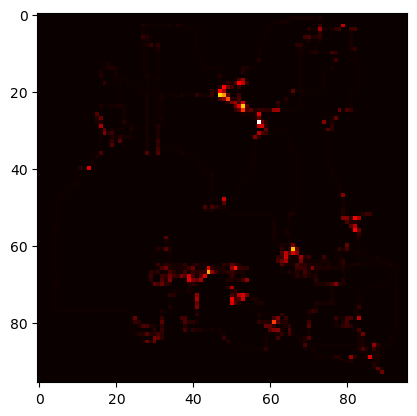

30.0
(array([7854,  682,  201,  100,   62,   43,   34,   33,   27,   20,   21,
         15,   11,    8,   10,    8,    7,    3,   10,    6,    4,    2,
          3,    8,    1,    3,    3,    0,    3,    3,    2,    3,    4,
          2,    4,    0,    1,    1,    3,    1,    0,    1,    0,    0,
          0,    1,    0,    1,    0,    1,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    1,    0,    0,    0,
          1,    0,    1,    0,    1,    1,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    1,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0], dtype=int64), array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,

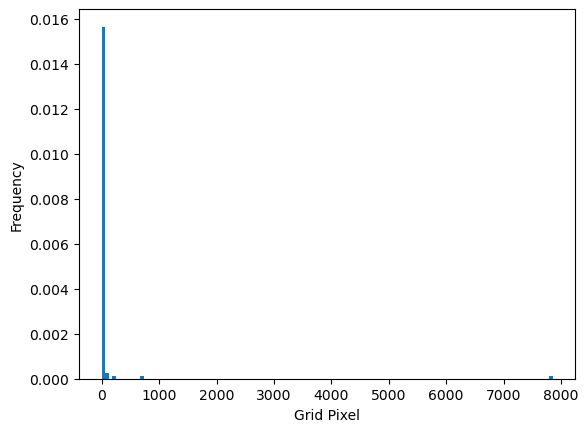

"\nif len(x_single_ep.index) > 0:\n                    for k in range(len(x_single_ep.index)):                         \n                        xi = int(x_single_ep.loc[k,'player_position_x'])\n                        yi = int(x_single_ep.loc[k,'player_position_y'])\n                        path_intensity[xi,yi] = path_intensity[xi,yi] + 1\n                \n                _bins = MapSize * MapSize\n                path_hist, _ = np.histogram(path_intensity.ravel(), bins=_bins, range=(0, _bins)) \n                prob_dist = path_hist / path_hist.sum()\n                path_entropy = entropy(prob_dist, base=2)\n                plt.hist(path_hist, density=1, bins=_bins)\n                plt.xlabel('Grid Pixel')\n                plt.ylabel('Frequency')\n"

In [7]:
# Example spatial entropy calculation for a position heatmap

k = 0
test1 = int(x_single_ep.loc[k,'player_position_x'])
test2= int(x_single_ep.loc[k,'player_position_y'])
_bins = 128
#path_intensity[test1,test2] = path_intensity[test1,test2]
#print(path_intensity[test1,test2])
#path_intensity[test1,test2] = path_intensity[test1,test2] + 1
plt.imshow(path_intensity, cmap='hot', interpolation='nearest')
plt.show()
print(path_intensity[test1,test2])
print(np.histogram(path_intensity.ravel(), bins=_bins, range=(0, _bins)) )
path_hist, _ = np.histogram(path_intensity.ravel(), bins=_bins, range=(0, _bins)) 
prob_dist = path_hist / path_hist.sum()
print(prob_dist)
path_entropy = entropy(prob_dist, base=2)
print('entropy: ', path_entropy)
plt.hist(path_hist, density=1, bins=_bins)
plt.xlabel('Grid Pixel')
plt.ylabel('Frequency')
plt.show()

'''
if len(x_single_ep.index) > 0:
                    for k in range(len(x_single_ep.index)):                         
                        xi = int(x_single_ep.loc[k,'player_position_x'])
                        yi = int(x_single_ep.loc[k,'player_position_y'])
                        path_intensity[xi,yi] = path_intensity[xi,yi] + 1
                
                _bins = MapSize * MapSize
                path_hist, _ = np.histogram(path_intensity.ravel(), bins=_bins, range=(0, _bins)) 
                prob_dist = path_hist / path_hist.sum()
                path_entropy = entropy(prob_dist, base=2)
                plt.hist(path_hist, density=1, bins=_bins)
                plt.xlabel('Grid Pixel')
                plt.ylabel('Frequency')
'''

In [16]:
#this block does averaging and stats across runs

maxAgentLengthID = 1 # 14 # if runs of different length are used

for idx in range(len(EpNumDict[f"agent_{maxAgentLengthID}"])):
    PredRateDict[f"ep_{idx}"] = []
    ExplorationDistanceDict[f"ep_{idx}"] = []
    HungerRateDict[f"ep_{idx}"] = []
    FatigueRateDict[f"ep_{idx}"] = []
    ThirstRateDict[f"ep_{idx}"] = []
    UncertaintyDict[f"ep_{idx}"] = []
    PredKillDict[f"ep_{idx}"] = []
    NumToolsDict[f"ep_{idx}"] = []
    EpNumDict[f"ep_{idx}"] = []
    EarlyAngleDict[f"ep_{idx}"] = []
    LateAngleDict[f"ep_{idx}"] = []
    EarlyDistDict[f"ep_{idx}"] = []
    LateDistDict[f"ep_{idx}"] = []
    EntropyDict[f"ep_{idx}"] = []
    LogPDict[f"ep_{idx}"] = []
    CrossEntropyDict[f"ep_{idx}"] = []
    
    #EarlyAngleHungerDict = {}
    #LateAngleHungerDict = {}
    #EarlyDistHungerDict = {}
    #LateDistHungerDict = {}
    #EarlyHungerDict = {}
    #LateHungerDict = {}
    

List_sorted_EpNum = []
List_sorted_PredRate = []
List_sorted_ExplorationDistance = []
List_sorted_HungerRate = []
List_sorted_FatigueRate = []
List_sorted_ThirstRate = []
List_sorted_Uncertainty = []
List_sorted_PredKill = []
List_sorted_NumTools = []
List_sorted_EarlyAngle = []
List_sorted_LateAngle = []
List_sorted_EarlyDist = []
List_sorted_LateDist = []
List_sorted_Entropy = []
List_sorted_CrossEntropy = []
List_sorted_LogP = []

List_sorted_EpNumSTD = []
List_sorted_PredRateSTD = []
List_sorted_ExplorationDistanceSTD = []
List_sorted_HungerRateSTD = []
List_sorted_FatigueRateSTD = []
List_sorted_ThirstRateSTD = []
List_sorted_UncertaintySTD = []
List_sorted_PredKillSTD = []
List_sorted_NumToolsSTD = []
List_sorted_EarlyAngleSTD = []
List_sorted_LateAngleSTD = []
List_sorted_EarlyDistSTD = []
List_sorted_LateDistSTD = []
List_sorted_EntropySTD = []
List_sorted_CrossEntropySTD = []
List_sorted_LogPSTD = []

#for idx in range(len(sorted_EpNum0)):    
for idx in range(len(EpNumDict[f"agent_{maxAgentLengthID}"])):
    for agentID in range(maxAgent):
        if idx < len(PredRateDict[f"agent_{agentID}"]):
            PredRateDict[f"ep_{idx}"].append(PredRateDict[f"agent_{agentID}"][idx])
            ExplorationDistanceDict[f"ep_{idx}"].append(ExplorationDistanceDict[f"agent_{agentID}"][idx])
            HungerRateDict[f"ep_{idx}"].append(HungerRateDict[f"agent_{agentID}"][idx])
            FatigueRateDict[f"ep_{idx}"].append(FatigueRateDict[f"agent_{agentID}"][idx])
            ThirstRateDict[f"ep_{idx}"].append(ThirstRateDict[f"agent_{agentID}"][idx])
            UncertaintyDict[f"ep_{idx}"].append(UncertaintyDict[f"agent_{agentID}"][idx])
            PredKillDict[f"ep_{idx}"].append(PredKillDict[f"agent_{agentID}"][idx])
            NumToolsDict[f"ep_{idx}"].append(NumToolsDict[f"agent_{agentID}"][idx])
            EpNumDict[f"ep_{idx}"].append(EpNumDict[f"agent_{agentID}"][idx])
            EarlyAngleDict[f"ep_{idx}"].append(EarlyAngleDict[f"agent_{agentID}"][idx])
            LateAngleDict[f"ep_{idx}"].append(LateAngleDict[f"agent_{agentID}"][idx])
            EarlyDistDict[f"ep_{idx}"].append(EarlyDistDict[f"agent_{agentID}"][idx])
            LateDistDict[f"ep_{idx}"].append(LateDistDict[f"agent_{agentID}"][idx])
            EntropyDict[f"ep_{idx}"].append(EntropyDict[f"agent_{agentID}"][idx])
            if hasEntropy == 1:
                LogPDict[f"ep_{idx}"].append(LogPDict[f"agent_{agentID}"][idx])
                CrossEntropyDict[f"ep_{idx}"].append(CrossEntropyDict[f"agent_{agentID}"][idx])
    
    List_sorted_EpNum.append( np.nanmean( np.array(EpNumDict[f"ep_{idx}"]) ) )
    List_sorted_PredRate.append( np.nanmean( np.array(PredRateDict[f"ep_{idx}"]) ) )
    List_sorted_ExplorationDistance.append( np.nanmean( np.array(ExplorationDistanceDict[f"ep_{idx}"]) ) )
    List_sorted_HungerRate.append( np.nanmean( np.array(HungerRateDict[f"ep_{idx}"]) ) )
    List_sorted_FatigueRate.append( np.nanmean( np.array(FatigueRateDict[f"ep_{idx}"]) ) )
    List_sorted_ThirstRate.append( np.nanmean( np.array(ThirstRateDict[f"ep_{idx}"]) ) )
    List_sorted_Uncertainty.append( np.nanmean( np.array(UncertaintyDict[f"ep_{idx}"]) ) )
    List_sorted_PredKill.append( np.nanmean( np.array(PredKillDict[f"ep_{idx}"]) ) )
    List_sorted_NumTools.append( np.nanmean( np.array(NumToolsDict[f"ep_{idx}"]) ) )
    List_sorted_EarlyAngle.append( np.nanmean( np.array(EarlyAngleDict[f"ep_{idx}"]) ) )
    List_sorted_LateAngle.append( np.nanmean( np.array(LateAngleDict[f"ep_{idx}"]) ) )
    List_sorted_EarlyDist.append( np.nanmean( np.array(EarlyDistDict[f"ep_{idx}"]) ) )
    List_sorted_LateDist.append( np.nanmean( np.array(LateDistDict[f"ep_{idx}"]) ) )
    List_sorted_Entropy.append( np.nanmean( np.array(EntropyDict[f"ep_{idx}"]) ) )
    if hasEntropy == 1:
        List_sorted_CrossEntropy.append( np.nanmean( np.array(CrossEntropyDict[f"ep_{idx}"]) ) )
        List_sorted_LogP.append( np.nanmean( np.array(LogPDict[f"ep_{idx}"]) ) )
    
    List_sorted_EpNumSTD.append( np.nanstd( np.array(EpNumDict[f"ep_{idx}"]) ) )
    List_sorted_PredRateSTD.append( np.nanstd( np.array(PredRateDict[f"ep_{idx}"]) ) )
    List_sorted_ExplorationDistanceSTD.append( np.nanstd( np.array(ExplorationDistanceDict[f"ep_{idx}"]) ) )
    List_sorted_HungerRateSTD.append( np.nanstd( np.array(HungerRateDict[f"ep_{idx}"]) ) )
    List_sorted_FatigueRateSTD.append( np.nanstd( np.array(FatigueRateDict[f"ep_{idx}"]) ) )
    List_sorted_ThirstRateSTD.append( np.nanstd( np.array(ThirstRateDict[f"ep_{idx}"]) ) )
    List_sorted_UncertaintySTD.append( np.nanstd( np.array(UncertaintyDict[f"ep_{idx}"]) ) )
    List_sorted_PredKillSTD.append( np.nanstd( np.array(PredKillDict[f"ep_{idx}"]) ) )
    List_sorted_NumToolsSTD.append( np.nanstd( np.array(NumToolsDict[f"ep_{idx}"]) ) )
    List_sorted_EarlyAngleSTD.append( np.nanstd( np.array(EarlyAngleDict[f"ep_{idx}"]) ) )
    List_sorted_LateAngleSTD.append( np.nanstd( np.array(LateAngleDict[f"ep_{idx}"]) ) )
    List_sorted_EarlyDistSTD.append( np.nanstd( np.array(EarlyDistDict[f"ep_{idx}"]) ) )
    List_sorted_LateDistSTD.append( np.nanstd( np.array(LateDistDict[f"ep_{idx}"]) ) )
    List_sorted_EntropySTD.append( np.nanstd( np.array(EntropyDict[f"ep_{idx}"]) ) )
    if hasEntropy == 1:
        List_sorted_CrossEntropySTD.append( np.nanmean( np.array(CrossEntropyDict[f"ep_{idx}"]) ) )
        List_sorted_LogPSTD.append( np.nanmean( np.array(LogPDict[f"ep_{idx}"]) ) )

sorted_EpNum = np.array(List_sorted_EpNum)
sorted_PredRate = np.array(List_sorted_PredRate)
sorted_ExplorationDistance = np.array(List_sorted_ExplorationDistance)
sorted_HungerRate = np.array(List_sorted_HungerRate)
sorted_FatigueRate = np.array(List_sorted_FatigueRate)
sorted_ThirstRate = np.array(List_sorted_ThirstRate)
sorted_Uncertainty = np.array(List_sorted_Uncertainty)
sorted_PredKill = np.array(List_sorted_PredKill)
sorted_NumTools = np.array(List_sorted_NumTools)
sorted_EarlyAngle = np.array(List_sorted_EarlyAngle)
sorted_LateAngle = np.array(List_sorted_LateAngle)
sorted_EarlyDist = np.array(List_sorted_EarlyDist)
sorted_LateDist = np.array(List_sorted_LateDist)
sorted_Entropy = np.array(List_sorted_Entropy)
if hasEntropy == 1:
    sorted_CrossEntropy = np.array(List_sorted_CrossEntropy)
    sorted_LogP = np.array(List_sorted_LogP)

sorted_EpNumSTD = np.array(List_sorted_EpNumSTD) * 1.960 / np.sqrt(maxAgent)
sorted_PredRateSTD = np.array(List_sorted_PredRateSTD) * 1.960 * np.sqrt(maxAgent)
sorted_ExplorationDistanceSTD = np.array(List_sorted_ExplorationDistanceSTD) * 1.960 / np.sqrt(maxAgent)
sorted_HungerRateSTD = np.array(List_sorted_HungerRateSTD) * 1.960 / np.sqrt(maxAgent)
sorted_FatigueRateSTD = np.array(List_sorted_FatigueRateSTD) * 1.960 / np.sqrt(maxAgent)
sorted_ThirstRateSTD = np.array(List_sorted_ThirstRateSTD) * 1.960 / np.sqrt(maxAgent)
sorted_UncertaintySTD = np.array(List_sorted_UncertaintySTD) * 1.960 / np.sqrt(maxAgent)
sorted_PredKillSTD = np.array(List_sorted_PredKillSTD) * 1.960 / np.sqrt(maxAgent)
sorted_NumToolsSTD = np.array(List_sorted_NumToolsSTD) * 1.960 / np.sqrt(maxAgent)
sorted_EarlyAngleSTD = np.array(List_sorted_EarlyAngleSTD) * 1.960 / np.sqrt(maxAgent)
sorted_LateAngleSTD = np.array(List_sorted_LateAngleSTD) * 1.960 / np.sqrt(maxAgent)
sorted_EarlyDistSTD = np.array(List_sorted_EarlyDistSTD) * 1.960 / np.sqrt(maxAgent)
sorted_LateDistSTD = np.array(List_sorted_LateDistSTD) * 1.960 / np.sqrt(maxAgent)
sorted_EntropySTD = np.array(List_sorted_EntropySTD) * 1.960 / np.sqrt(maxAgent)
if hasEntropy == 1:
    sorted_CrossEntropySTD = np.array(List_sorted_CrossEntropySTD) * 1.960 / np.sqrt(maxAgent)
    sorted_LogPSTD = np.array(List_sorted_LogPSTD) * 1.960 / np.sqrt(maxAgent)

ValueError: zero-size array to reduction operation fmax which has no identity

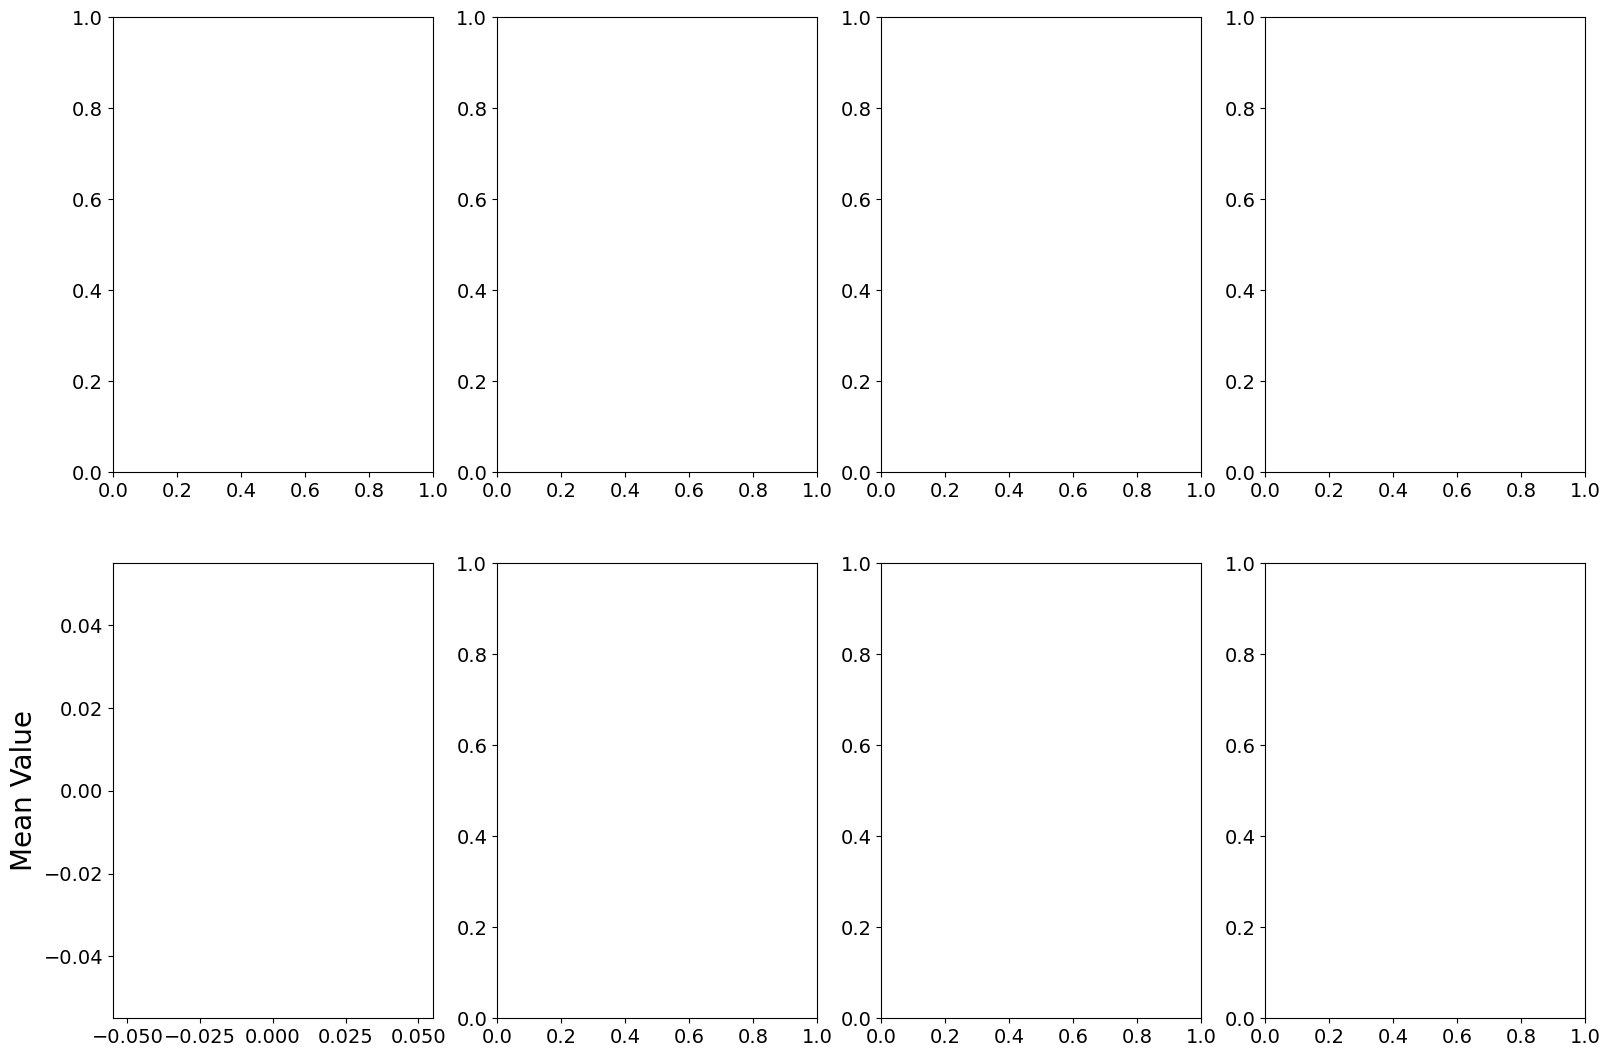

In [17]:
UncToDistRatio = sorted_Uncertainty/sorted_ExplorationDistance # make a variable that is spatial uncertainty 
#(position prediction error) normalized by the max distance radius explored per ep
move_ave = False #whether to smooth the plots or not
isNormalize = False #normalize variables to max of run, not recommended because can obscure trends
hasEntropy = 0

if move_ave == True:
    window = 3
    if isNormalize == True:
        ma_PredRate = moving_average(sorted_PredRate/np.nanmax(sorted_PredRate), window)
        ma_ExplorationDistance = moving_average(sorted_ExplorationDistance/np.nanmax(sorted_ExplorationDistance), window)
        ma_HungerRate = moving_average(sorted_HungerRate/np.nanmax(sorted_HungerRate), window)
        ma_ThirstRate = moving_average(sorted_ThirstRate/np.nanmax(sorted_ThirstRate), window)
        ma_Uncertainty = moving_average(sorted_Uncertainty/np.nanmax(sorted_Uncertainty), window)
        ma_FatigueRate = moving_average(sorted_FatigueRate/np.nanmax(sorted_FatigueRate), window)
        ma_UncToDistRatio = moving_average(UncToDistRatio/np.nanmax(UncToDistRatio), window)
        ma_PredKill = moving_average(sorted_PredKill/np.nanmax(sorted_PredKill), window)
        ma_NumTools = moving_average(sorted_NumTools/np.nanmax(sorted_NumTools), window)
        ma_EpNum = sorted_EpNum[1:(len(sorted_EpNum)-1)]
    
    if isNormalize == False:
        ma_PredRate = moving_average(sorted_PredRate, window)
        ma_ExplorationDistance = moving_average(sorted_ExplorationDistance, window)
        ma_HungerRate = moving_average(sorted_HungerRate, window)
        ma_ThirstRate = moving_average(sorted_ThirstRate, window)
        ma_Uncertainty = moving_average(sorted_Uncertainty, window)
        ma_FatigueRate = moving_average(sorted_FatigueRate, window)
        ma_UncToDistRatio = moving_average(UncToDistRatio, window)
        ma_PredKill = moving_average(sorted_PredKill, window)
        ma_NumTools = moving_average(sorted_NumTools, window)
        ma_EarlyAngle = moving_average(sorted_EarlyAngle, window)
        ma_LateAngle = moving_average(sorted_LateAngle, window)
        ma_EarlyDist = moving_average(sorted_EarlyDist, window)
        ma_LateDist = moving_average(sorted_LateDist, window)
        ma_Entropy = moving_average(sorted_Entropy, window)
        ma_EpNum = sorted_EpNum[1:(len(sorted_EpNum)-1)]/1000
        
        #sorted_EpNumSTD = sorted_EpNumSTD[1:(len(sorted_EpNum)-1)]
        sorted_PredRateSTD = sorted_PredRateSTD[1:(len(sorted_PredRateSTD)-1)]
        sorted_ExplorationDistanceSTD = sorted_ExplorationDistanceSTD[1:(len(sorted_EpNum)-1)]
        sorted_HungerRateSTD = sorted_HungerRateSTD[1:(len(sorted_EpNum)-1)]
        sorted_FatigueRateSTD = sorted_FatigueRateSTD[1:(len(sorted_EpNum)-1)]
        sorted_ThirstRateSTD = sorted_ThirstRateSTD[1:(len(sorted_EpNum)-1)]
        sorted_UncertaintySTD = sorted_UncertaintySTD[1:(len(sorted_EpNum)-1)]
        sorted_PredKillSTD = sorted_PredKillSTD[1:(len(sorted_EpNum)-1)]
        sorted_NumToolsSTD = sorted_NumToolsSTD[1:(len(sorted_EpNum)-1)]
        sorted_EarlyAngleSTD = sorted_EarlyAngleSTD[1:(len(sorted_EpNum)-1)]
        sorted_LateAngleSTD = sorted_LateAngleSTD[1:(len(sorted_EpNum)-1)]
        sorted_EarlyDistSTD = sorted_EarlyDistSTD[1:(len(sorted_EpNum)-1)]
        sorted_LateDistSTD = sorted_LateDistSTD[1:(len(sorted_EpNum)-1)]
        sorted_EntropySTD = sorted_EntropySTD[1:(len(sorted_EpNum)-1)]
        #sorted_UncertaintySTD = sorted_UncertaintySTD[1:(len(sorted_EpNum)-1)]
    
if move_ave == False:
    if isNormalize == True:
        ma_PredRate = sorted_PredRate/np.nanmax(sorted_PredRate)
        ma_ExplorationDistance = sorted_ExplorationDistance/np.nanmax(sorted_ExplorationDistance)
        ma_HungerRate = sorted_HungerRate/np.nanmax(sorted_HungerRate)
        ma_ThirstRate = sorted_ThirstRate/np.nanmax(sorted_ThirstRate)
        ma_Uncertainty = sorted_Uncertainty/np.nanmax(sorted_Uncertainty)
        ma_FatigueRate = sorted_FatigueRate/np.nanmax(sorted_FatigueRate)
        ma_UncToDistRatio = UncToDistRatio/np.nanmax(UncToDistRatio)
        ma_PredKill = sorted_PredKill/np.nanmax(sorted_PredKill)
        ma_NumTools = sorted_NumTools/np.nanmax(sorted_NumTools)
        ma_EarlyAngle = sorted_EarlyAngle/np.nanmax(sorted_EarlyAngle)
        ma_LateAngle = sorted_LateAngle/np.nanmax(sorted_LateAngle)
        ma_EarlyDist = sorted_EarlyDist/np.nanmax(sorted_EarlyDist)
        ma_LateDist = sorted_LateDist/np.nanmax(sorted_LateDist)
        ma_Entropy = sorted_Entropy/np.nanmax(sorted_Entropy)
        ma_EpNum = sorted_EpNum/1000
    if isNormalize == False:
        ma_PredRate = sorted_PredRate
        ma_ExplorationDistance = sorted_ExplorationDistance
        ma_HungerRate = sorted_HungerRate
        ma_ThirstRate = sorted_ThirstRate
        ma_Uncertainty = sorted_Uncertainty
        ma_FatigueRate = sorted_FatigueRate
        ma_UncToDistRatio = UncToDistRatio
        ma_PredKill = sorted_PredKill
        ma_NumTools = sorted_NumTools
        ma_EarlyAngle = sorted_EarlyAngle
        ma_LateAngle = sorted_LateAngle
        ma_EarlyDist = sorted_EarlyDist
        ma_LateDist = sorted_LateDist
        ma_Entropy = sorted_Entropy
        if hasEntropy == 1:
            ma_CrossEntropy = sorted_CrossEntropy
            ma_LogP = sorted_LogP
        ma_EpNum = sorted_EpNum/1000   

    
# Set global font size for axis numbers
plt.rcParams['xtick.labelsize'] = 14  # Change labelsize as needed
plt.rcParams['ytick.labelsize'] = 14    
    
ymin = 0
ymax = 1
xmin = 0
xmax = 125
if hasEntropy == 0:
    fig, axs = plt.subplots(2, 4)
    fig.set_figheight(13)
    fig.set_figwidth(19)
if hasEntropy == 1:
    fig, axs = plt.subplots(3, 4)
    fig.set_figheight(13)
    fig.set_figwidth(19)
axs[1, 0].plot(ma_EpNum, ma_PredRate, linewidth=3, marker='o')
if isNormalize == True:
    norm0 =  np.nanmax(sorted_PredRate)
    axs[1, 0].set_ylim([ymin, ymax])
    axs[1, 0].set_ylabel('Normalized Value',fontsize=20)
if isNormalize == False:    
    norm0 =  1
    axs[1, 0].set_ylabel('Mean Value',fontsize=20)
    axs[1, 0].set_ylim([0, np.nanmax(ma_PredRate+sorted_PredRateSTD) + 0.15*np.nanmax(ma_PredRate+sorted_PredRateSTD)])
axs[1, 0].fill_between(ma_EpNum, ma_PredRate-sorted_PredRateSTD/norm0,
                       ma_PredRate+sorted_PredRateSTD/norm0,alpha=0.3)
axs[1, 0].set_title('Pred. Enc. Rate',fontsize=20)
axs[1, 0].set_xlim([xmin, xmax])

#axs[0, 1].plot(ma_EpNum, ma_ExplorationDistance,color='brown', linewidth=3)
#if isNormalize == True:
#    norm0 =  np.nanmax(sorted_ExplorationDistance)
#    axs[0, 1].set_ylim([ymin, ymax])
#if isNormalize == False:    
#    norm0 =  1
#    axs[0, 1].set_ylim([0, 40])
#axs[0, 1].fill_between(ma_EpNum, ma_ExplorationDistance-sorted_ExplorationDistanceSTD/norm0,
#                       ma_ExplorationDistance+sorted_ExplorationDistanceSTD/norm0,
#                       alpha=0.3,color='brown')
axs[0, 1].set_title("Distance Traveled",fontsize=20)
axs[0, 1].set_xlim([xmin, xmax])

axs[1, 3].plot(ma_EpNum, ma_HungerRate,color='red', linewidth=3, marker='o')
axs[1, 3].plot(ma_EpNum, ma_ThirstRate,color='purple', linewidth=3, marker='o')
if isNormalize == True:
    norm0 =  np.nanmax(sorted_HungerRate)
    axs[1, 3].set_ylim([ymin, ymax])
if isNormalize == False:    
    norm0 =  1
    axs[1, 3].set_ylim([1, 8.5])
axs[1, 3].fill_between(ma_EpNum, ma_HungerRate-sorted_HungerRateSTD/norm0,
                       ma_HungerRate+sorted_HungerRateSTD/norm0,alpha=0.3,color='red')
axs[1, 3].set_title('Food & Drink Score',fontsize=20)
axs[1, 3].set_xlim([xmin, xmax])
axs[1, 3].plot(ma_EpNum, ma_ThirstRate,color='purple', linewidth=3, marker='o')
if isNormalize == True:
    norm0 =  np.nanmax(sorted_ThirstRate)
    axs[1, 3].set_ylim([ymin, ymax])
if isNormalize == False:    
    norm0 =  1
    axs[1, 3].set_ylim([1, 8.5])
axs[1, 3].fill_between(ma_EpNum, ma_ThirstRate-sorted_ThirstRateSTD/norm0,
                       ma_ThirstRate+sorted_ThirstRateSTD/norm0,alpha=0.3,color='purple')
#axs[0, 3].set_title('Drink Score',fontsize=20)
#axs[0, 2].set_xlim([xmin, xmax])
axs[1,3].legend(['Food Score','Drink Score'],fontsize =15)

#axs[1, 1].plot(ma_EpNum, ma_Uncertainty,color='black', linewidth=3)
#axs[1, 1].fill_between(ma_EpNum, ma_Uncertainty-sorted_UncertaintySTD/np.max(sorted_Uncertainty),
#                       ma_Uncertainty+sorted_UncertaintySTD/np.max(sorted_Uncertainty),alpha=0.3,color='black')
#axs[1, 1].set_title("Spatial Uncertainty",fontsize=20)
#axs[1, 1].set_ylim([ymin, ymax])

axs[0, 0].plot(ma_EpNum, ma_UncToDistRatio,color='gray', linewidth=3, marker='o')
if isNormalize == True:
    norm0 =  (np.nanmax(ma_UncToDistRatio)*sorted_ExplorationDistance)
    axs[0, 0].set_ylim([ymin, ymax])
    axs[0, 0].set_ylabel('Normalized Value',fontsize=20)
if isNormalize == False:    
    if move_ave == True:
        norm0 =  sorted_ExplorationDistance[1:(len(sorted_ExplorationDistance)-1)]
    if move_ave == False:
        norm0 =  sorted_ExplorationDistance    
    axs[0, 0].set_ylabel('Mean Value',fontsize=20)
    axs[0, 0].set_ylim([0, 0.4])
axs[0, 0].fill_between(ma_EpNum, ma_UncToDistRatio-sorted_UncertaintySTD/norm0,
                       ma_UncToDistRatio+sorted_UncertaintySTD/norm0,
                       alpha=0.3,color='gray')
axs[0, 0].set_title('Spatial Unc. / Distance',fontsize=20)

axs[0, 0].set_xlim([xmin, xmax])

axs[1, 1].plot(ma_EpNum, ma_PredKill,color='orange', linewidth=3, marker='o')
if isNormalize == True:
    norm0 =  np.nanmax(ma_PredKill)
    axs[1, 1].set_ylim([ymin, ymax])
if isNormalize == False:    
    norm0 =  1
axs[1, 1].fill_between(ma_EpNum, ma_PredKill-sorted_PredKillSTD/norm0,
                       ma_PredKill+sorted_PredKillSTD/norm0,alpha=0.3,color='orange')
axs[1, 1].set_title("Pred. Kill Rate",fontsize=20)
axs[1, 1].set_xlim([xmin, xmax])
axs[1, 1].set_ylim([0, 28])
#axs[1, 2].set_xlabel('Ep. Number',fontsize=20)


axs[1, 2].plot(ma_EpNum, ma_NumTools,color='pink', linewidth=3, marker='o')
if isNormalize == True:
    norm0 =  np.nanmax(ma_NumTools)
    axs[1, 2].set_ylim([ymin, ymax])
if isNormalize == False:    
    norm0 =  1
axs[1, 2].fill_between(ma_EpNum, ma_NumTools-sorted_NumToolsSTD/norm0,
                   ma_NumTools+sorted_NumToolsSTD/norm0,alpha=0.3,color='pink')
axs[1, 2].set_title("Tool Make Rate",fontsize=20)
axs[1, 2].set_xlim([xmin, xmax])

axs[0, 3].plot(ma_EpNum, ma_EarlyAngle,color='cyan', linewidth=3, marker='o')
axs[0, 3].plot(ma_EpNum, ma_LateAngle,color='magenta', linewidth=3, marker='o')
if isNormalize == True:
    norm0 =  np.nanmax(ma_EarlyAngle)
    axs[0, 3].set_ylim([ymin, ymax])
if isNormalize == False:    
    norm0 =  1
    axs[0, 3].set_ylim([0.1, 0.7])
axs[0, 3].fill_between(ma_EpNum, ma_EarlyAngle-sorted_EarlyAngleSTD/norm0,
                   ma_EarlyAngle+sorted_EarlyAngleSTD/norm0,alpha=0.3,color='cyan')
axs[0, 3].set_title("Angular Variance",fontsize=20)
axs[0, 3].set_xlim([xmin, xmax])
if isNormalize == True:
    norm0 =  np.nanmax(ma_LateAngle)
    axs[0, 3].set_ylim([ymin, ymax])
    axs[0, 3].set_ylabel('Normalized Value',fontsize=20)
if isNormalize == False:    
    norm0 =  1
    axs[0, 3].set_ylim([0.1, 0.7])
axs[0, 3].fill_between(ma_EpNum, ma_LateAngle-sorted_LateAngleSTD/norm0,
                   ma_LateAngle+sorted_LateAngleSTD/norm0,alpha=0.3,color='magenta')
#axs[2, 0].set_title("Late Angle Var., RWsize"+str(windowSize),fontsize=20)
#axs[2, 0].set_title("Late Angular Variance",fontsize=20)
axs[0, 3].set_xlim([xmin, xmax])
axs[0,3].legend(['Early in Episode','Late in Episode'],fontsize =15)


axs[0, 1].plot(ma_EpNum, ma_EarlyDist,color='green', linewidth=3, marker='o')
axs[0, 1].plot(ma_EpNum, ma_LateDist,color='blue', linewidth=3, marker='o')
if isNormalize == True:
    norm0 =  np.nanmax(ma_EarlyDist)
    axs[0, 1].set_ylim([ymin, ymax])
if isNormalize == False:    
    norm0 =  1
    axs[0, 1].set_ylim([0, 50])
axs[0,1].fill_between(ma_EpNum, ma_EarlyDist-sorted_EarlyDistSTD/norm0,
                   ma_EarlyDist+sorted_EarlyDistSTD/norm0,alpha=0.3,color='green')
#axs[2, 1].set_title("Early Mean Dist.",fontsize=20)
axs[0, 1].set_xlim([xmin, xmax])
if isNormalize == True:
    norm0 =  np.nanmax(ma_LateDist)
    axs[0, 1].set_ylim([ymin, ymax])
if isNormalize == False:    
    norm0 =  1
    axs[0, 1].set_ylim([0, 50])
axs[0, 1].fill_between(ma_EpNum, ma_LateDist-sorted_LateDistSTD/norm0,
                   ma_LateDist+sorted_LateDistSTD/norm0,alpha=0.3,color='blue')
#axs[2, 2].set_title("Late Mean Dist.",fontsize=20)
axs[0, 1].set_xlim([xmin, xmax])
axs[0, 1].legend(['Early in Episode','Late in Episode'],fontsize=15)

axs[0, 2].plot(ma_EpNum, ma_Entropy,color='olive', linewidth=3, marker='o')
if isNormalize == True:
    norm0 =  np.nanmax(ma_Entropy)
    axs[0, 2].set_ylim([ymin, ymax])
if isNormalize == False:    
    norm0 =  1
    #axs[2, 3].set_ylim([0, 40])
axs[0, 2].fill_between(ma_EpNum, ma_Entropy-sorted_EntropySTD/norm0,
                   ma_Entropy+sorted_EntropySTD/norm0,alpha=0.3,color='olive')
axs[0, 2].set_title("Spatial Entropy",fontsize=20)
axs[0, 2].set_xlim([xmin, xmax])

if hasEntropy == 0:
    axs[1, 0].set_xlabel('Ep. Number (1000x)',fontsize=20)
    axs[1, 1].set_xlabel('Ep. Number (1000x)',fontsize=20)
    axs[1, 2].set_xlabel('Ep. Number (1000x)',fontsize=20)
    axs[1, 3].set_xlabel('Ep. Number (1000x)',fontsize=20)
    
if hasEntropy == 1:
    
    axs[2, 0].plot(ma_EpNum, ma_CrossEntropy, linewidth=3, marker='o',color='black')
    if isNormalize == True:
        norm0 =  np.nanmax(sorted_CrossEntropy)
        axs[2, 0].set_ylim([ymin, ymax])
        axs[2, 0].set_ylabel('Normalized Value',fontsize=20)
    if isNormalize == False:    
        norm0 =  1
        axs[2, 0].set_ylabel('Mean Value',fontsize=20)
        axs[2, 0].set_ylim([0, np.nanmax(ma_CrossEntropy+sorted_CrossEntropySTD) + 0.15*np.nanmax(ma_CrossEntropy+sorted_CrossEntropySTD)])
    axs[2, 0].fill_between(ma_EpNum, ma_CrossEntropy-sorted_CrossEntropySTD/norm0,
                           ma_CrossEntropy+sorted_CrossEntropySTD/norm0,alpha=0.3,color='black')
    axs[2, 0].set_title('Cross Entropy Ave.',fontsize=20)
    axs[2, 0].set_xlim([xmin, xmax])
    
    axs[2, 1].plot(ma_EpNum, ma_LogP, linewidth=3, marker='o',color='brown')
    if isNormalize == True:
        norm0 =  np.nanmax(sorted_LogP)
        axs[2, 1].set_ylim([ymin, ymax])
        axs[2, 1].set_ylabel('Normalized Value',fontsize=20)
    if isNormalize == False:    
        norm0 =  1
        axs[2, 1].set_ylabel('Mean Value',fontsize=20)
        axs[2, 1].set_ylim([0, np.nanmax(ma_LogP+sorted_LogPSTD) + 0.15*np.nanmax(ma_LogP+sorted_LogPSTD)])
    axs[2, 1].fill_between(ma_EpNum, ma_LogP-sorted_LogPSTD/norm0,
                           ma_LogP+sorted_LogPSTD/norm0,alpha=0.3,color='brown')
    axs[2, 1].set_title('Log P Ave.',fontsize=20)
    axs[2, 1].set_xlim([xmin, xmax])
    
    axs[2, 0].set_xlabel('Ep. Number (1000x)',fontsize=20)
    axs[2, 1].set_xlabel('Ep. Number (1000x)',fontsize=20)
    axs[2, 2].set_xlabel('Ep. Number (1000x)',fontsize=20)
    axs[2, 3].set_xlabel('Ep. Number (1000x)',fontsize=20)    
'''
plt.plot(ma_EpNum, ma_PredRate, label = "Pred. Enc. Rate")
plt.fill_between(ma_EpNum, ma_PredRate-sorted_PredRateSTD,ma_PredRate+sorted_PredRateSTD,alpha=0.3)
plt.plot(ma_EpNum, ma_ExplorationDistance, label = "Dist. Traveled")
plt.plot(ma_EpNum, ma_HungerRate, label = "Food Score")
plt.plot(ma_EpNum, ma_ThirstRate, label = "Drink Score")
plt.plot(ma_EpNum, ma_Uncertainty, label = "Uncertainty")
plt.plot(ma_EpNum, ma_FatigueRate, label = "Energy Score")
plt.plot(ma_EpNum, ma_UncToDistRatio, label = "Spatial Unc. / Dist.")
plt.plot(ma_EpNum, ma_PredKill, label = "Pred. Kill Rates")
plt.plot(ma_EpNum, ma_NumTools, label = "Tool Making Rate")
plt.xlabel ('Training Episode Number')
plt.ylabel ('Normalized Mean Variable Value')
plt.title ('Multivariable Learning History Plot - Sparse Network')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()
'''
#sorted_EpNumSTD = np.array(List_sorted_EpNumSTD)
#sorted_PredRateSTD = np.array(List_sorted_PredRateSTD)
#sorted_ExplorationDistanceSTD = np.array(List_sorted_ExplorationDistanceSTD)
#sorted_HungerRateSTD = np.array(List_sorted_HungerRateSTD)
#sorted_FatigueRateSTD = np.array(List_sorted_FatigueRateSTD)
#sorted_ThirstRateSTD = np.array(List_sorted_ThirstRateSTD)
#sorted_UncertaintySTD = np.array(List_sorted_UncertaintySTD)
#sorted_PredKillSTD = np.array(List_sorted_PredKillSTD)
#sorted_NumToolsSTD = np.array(List_sorted_NumToolsSTD)

In [ ]:
#some extra diagnostic plots, histogramming all data points per var regardless of epoch number
PredRateAll = np.array(listPredRateAll)
ExplorationDistanceAll = np.array(listExplorationDistanceAll)
#EatRateAll.append(meanHungerRate)
HungerRateAll = np.array(listHungerRateAll)
FatigueRateAll = np.array(listFatigueRateAll)
ThirstRateAll = np.array(listThirstRateAll)
UncertaintyAll = np.array(listUncertaintyAll)
UncertaintyDistAll = np.array(listUncertaintyDistAll)
PredKillAll = np.array(listPredKillAll)
NumToolsAll = np.array(listNumToolsAll)
EpNumAll = np.array(listEpNumAll)
EpLengthAll = np.array(listEpLengthAll)


EarlyAngleAll = np.array(listEarlyAngleAll)
LateAngleAll = np.array(listLateAngleAll)
EarlyDistAll = np.array(listEarlyDistAll)
LateDistAll = np.array(listLateDistAll)

EarlyAngleHunger = np.array(listEarlyAngle_Hunger)
LateAngleHunger = np.array(listLateAngle_Hunger)
EarlyDistHunger = np.array(listEarlyDist_Hunger)
LateDistHunger = np.array(listLateDist_Hunger)
EarlyHunger  = np.array(listEarly_Hunger)
LateHunger = np.array(listLate_Hunger)

filtered_EarlyAngleAll = []
filtered_Early_EpLengthAll = []
filtered_LateAngleAll = []
filtered_Late_EpLengthAll = []

filtered_EarlyDistAll = []
filtered_Early_EpLengthAll = []
filtered_LateDistAll = []
filtered_Late_EpLengthAll = []

for i in range(len(listEarlyAngleAll)):
    if listEarlyAngleAll[i] > 0:
        filtered_EarlyAngleAll.append(listEarlyAngleAll[i])
        filtered_EarlyDistAll.append(listEarlyDistAll[i])
        filtered_Early_EpLengthAll.append(listEpLengthAll[i]/ 1000)
        
for i in range(len(listLateAngleAll)):
    if listLateAngleAll[i] > 0:
        filtered_LateAngleAll.append(listLateAngleAll[i])
        filtered_LateDistAll.append(listLateDistAll[i])
        filtered_Late_EpLengthAll.append(listEpLengthAll[i]/ 1000)
                
for i in range(len(listLateAngleAll)):
    EpLengthAll[i] = EpLengthAll[i] / 1000    

            
fig, axs = plt.subplots(3, 4)
fig.set_figheight(15)
fig.set_figwidth(15)
axs[0, 0].scatter(PredRateAll, EpLengthAll)
axs[0, 0].set_title('Pred. Enc. Rate',fontsize=20)
axs[0, 0].set_ylabel('Ep. Length (1000x)',fontsize=20)

axs[0, 1].scatter(ExplorationDistanceAll,EpLengthAll ,color='brown', linewidth=3)
axs[0, 1].set_title("Dist. Traveled",fontsize=20)

axs[0, 2].scatter(HungerRateAll, EpLengthAll,color='red', linewidth=3)
axs[0, 2].set_title('Food Score',fontsize=20)

axs[0, 3].scatter(ThirstRateAll, EpLengthAll,color='purple', linewidth=3)
axs[0, 3].set_title('Drink Score',fontsize=20)

axs[1, 0].scatter(UncertaintyDistAll, EpLengthAll,color='gray', linewidth=3)
axs[1, 0].set_title('Spatial Unc. / Dist.',fontsize=20)
axs[1, 0].set_ylabel('Ep. Length (1000x)',fontsize=20)

axs[1, 1].scatter(PredKillAll, EpLengthAll,color='orange', linewidth=3)
axs[1, 1].set_title("Pred. Kill Rates",fontsize=20)

axs[1, 2].scatter(NumToolsAll, EpLengthAll,color='magenta', linewidth=3)
axs[1, 2].set_title("Tool Make Rate",fontsize=20)

axs[1, 3].scatter(filtered_EarlyAngleAll, filtered_Early_EpLengthAll,color='cyan', linewidth=3)
axs[1, 3].set_title("Early Angle Var., RWsize"+str(windowSize),fontsize=20)
axs[1, 3].set_xlim([0, 1.5])

axs[2, 0].scatter(filtered_LateAngleAll, filtered_Late_EpLengthAll,color='pink', linewidth=3)
axs[2, 0].set_title("Late Angle Var., RWsize"+str(windowSize),fontsize=20)
axs[2, 0].set_xlabel('Mean Var. Value / Ep',fontsize=20)
axs[2, 0].set_ylabel('Ep. Length (1000x)',fontsize=20)
axs[2, 0].set_xlim([0, 1.5])


axs[2, 1].scatter(filtered_EarlyDistAll, filtered_Early_EpLengthAll,color='green', linewidth=3)
axs[2, 1].set_title("Early Dist.",fontsize=20)
axs[2, 1].set_xlabel('Mean Var. Value / Ep',fontsize=20)
axs[2, 1].set_xlim([0, 50])

axs[2, 2].scatter(filtered_LateDistAll, filtered_Late_EpLengthAll,color='blue', linewidth=3)
axs[2, 2].set_title("Late Dist.",fontsize=20)
axs[2, 2].set_xlabel('Mean Var. Value / Ep',fontsize=20)
axs[2, 2].set_xlim([0, 50])